# INFO3020 Week 5 — Tích hợp dữ liệu điểm thi THPT 2023

Notebook trình bày EX5.1–EX5.3 bằng kết quả chạy trên toàn bộ dữ liệu của dự án.
File báo cáo diễn giải riêng: `docs/week5_report+bao_cao.md`.
Notebook đọc các đầu ra do `src/main.py` tạo. Để tái tạo từ raw, chạy lệnh đó trước;
Run All của notebook kiểm tra và trình bày kết quả, không tự chạy lại pipeline.

Nguồn chính `data/raw/original.csv` được giữ bất biến. Nguồn bổ sung gồm 63 mã/tên từ bảng
Báo Chính phủ năm 2023 và mã 65 từ Phụ lục VIII, Công văn 1515/BGDĐT-QLCL. Xem
`docs/week5_source_mapping+anh_xa_nguon.md`. Điểm 0, null và ngoại lệ chưa xác minh
được giữ nguyên. Không scale hoặc encode dữ liệu EDA.


## EX5.1 — Pipeline có thể chạy lại

Thứ tự xử lý: đọc và kiểm tra nguồn → chuẩn hóa chuỗi và kiểm tra mã → loại dòng trùng hoàn toàn
(so trên cột gốc đã parse) → audit ID/điểm → giữ null → tính ngoại lệ IQR và Z-score → tạo nhóm môn theo điểm quan sát →
left merge danh mục năm 2023 → kiểm tra dữ liệu ghi/đọc lại.

`rows_before/after` đếm bản ghi ở mỗi bước; `scope_rows` là phạm vi được xét và có thể đếm ô;
`changed_rows` đếm dòng bị loại hoặc thay đổi giá trị gốc, không đếm việc thêm cột ngữ cảnh. Nhóm môn chỉ suy từ điểm có mặt, không khẳng định
thông tin đăng ký thi.


In [1]:
from pathlib import Path
import json
import pandas as pd

# Tìm thư mục repo khi chạy từ thư mục gốc hoặc từ notebooks/.
_root = Path(globals().get('__week5_repo_root__', Path.cwd())).resolve()
if not (_root / 'data/processed/week5_final+du_lieu_cuoi.csv').is_file():
    _root = _root.parent
if not (_root / 'data/processed/week5_final+du_lieu_cuoi.csv').is_file():
    raise FileNotFoundError('Chạy notebook từ thư mục repo hoặc notebooks/.')
_metrics = json.loads((_root / 'outputs/week5_manifest+ho_so_dau_ra.json').read_text(encoding='utf-8'))
print('Số dòng nguồn:', f"{_metrics['source']['main_rows']:,}")
print('Hash nguồn:', _metrics['source']['main_sha256'])
print('Số dòng sau pipeline:', f"{_metrics['output']['rows']:,}")
print('Hash dữ liệu cuối:', _metrics['output']['sha256'])
print('Kiểm tra round-trip đạt:', all(_metrics['validation'].values()))
print('\nNhật ký từng bước (phạm vi có thể đếm dòng hoặc ô, không cộng dồn):')
print(pd.read_csv(_root / 'outputs/tables/week5_pipeline_log+nhat_ky_quy_trinh.csv').to_string(index=False))


Số dòng nguồn: 1,022,060
Hash nguồn: cdf22a6b45f8e23b522beb1c521782e36486cac39d3fb64bca2a2395edec39b5
Số dòng sau pipeline: 1,022,060
Hash dữ liệu cuối: 75f1676ec0824ff2707b87fc8a1415ce497985e7eb9dec650d5ad0c5da756e23
Kiểm tra round-trip đạt: True

Nhật ký từng bước (phạm vi có thể đếm dòng hoặc ô, không cộng dồn):
                      step  rows_before  rows_after  rows_removed  scope_rows  changed_rows                                                                                     result
           01_read_sources            0     1022060             0     1022060             0                          Đọc CSV gốc và danh mục 2023; kiểm tra schema, hash, mã duy nhất.
   02_text_standardization      1022060     1022060             0     1022060             0            NFKC, strip, gộp whitespace; uppercase mã ngoại ngữ; kiểm tra mã sau chuẩn hóa.
03_exact_duplicate_removal      1022060     1022060             0     1022060             0         Loại bản ghi trùng hoàn toàn sau l

## Missing values và EX4 outlier flags được tái tính

Điểm thiếu được giữ; không tự gán nguyên nhân cho từng ô. IQR dùng phân vị tuyến tính:
`IQR=Q3−Q1`, cờ ngoài `[Q1−1,5×IQR; Q3+1,5×IQR]`. Z-score `Z=(x−μ)/σ` dùng `ddof=0`,
gắn cờ khi `|Z|>3`. Số cờ là số ô điểm; một thí sinh có thể bị gắn cờ ở nhiều môn.


In [2]:
missing = pd.read_csv(_root / 'outputs/tables/week5_missing_by_column+thieu_theo_cot.csv')
missing_group = pd.read_csv(_root / 'outputs/tables/week5_missing_group_summary+tong_hop_thieu_theo_nhom.csv')
outliers = pd.read_csv(_root / 'outputs/tables/week5_outlier_comparison+so_sanh_ngoai_le.csv')
print('Thiếu theo cột:')
print(missing.to_string(index=False))
print('\nThiếu theo nhóm điểm quan sát:')
print(missing_group.to_string(index=False))
print('\nSo sánh ngoại lệ theo môn:')
print(outliers[['column', 'n_observed', 'iqr_n', 'z_n', 'both_n', 'either_n']].to_string(index=False))


Thiếu theo cột:
               column  rows_total  missing_n  observed_n  missing_pct                                       decision
           Student ID     1022060          0     1022060     0.000000 Giữ null; không suy đoán nguyên nhân từng dòng
          Mathematics     1022060      18687     1003373     1.828366 Giữ null; không suy đoán nguyên nhân từng dòng
           Literature     1022060      13821     1008239     1.352269 Giữ null; không suy đoán nguyên nhân từng dòng
     Foreign language     1022060     141063      880997    13.801832 Giữ null; không suy đoán nguyên nhân từng dòng
              Physics     1022060     694871      327189    67.987300 Giữ null; không suy đoán nguyên nhân từng dòng
            Chemistry     1022060     693942      328118    67.896405 Giữ null; không suy đoán nguyên nhân từng dòng
              Biology     1022060     697435      324625    68.238166 Giữ null; không suy đoán nguyên nhân từng dòng
              History     1022060     338613    

**Giải nghĩa:** ở nhóm `science_only`, điểm thiếu ở ba môn xã hội là ứng viên thiếu cấu trúc;
ở `social_only`, điểm thiếu ở ba môn tự nhiên cũng vậy. Nhóm được suy từ điểm có mặt, không phải
hồ sơ đăng ký; nguyên nhân của từng ô chưa được xác minh. Các ô khác xếp `unresolved_cells`.
Tổng hai loại bằng `missing_score_cells`; chi tiết theo môn nằm ở
`outputs/tables/week5_missing_by_observed_group+thieu_theo_mon_va_nhom.csv`.


## EX5.2 — Ghép danh mục Hội đồng thi

Khóa ghép là `(exam_year=2023, exam_council_code)`, trong đó mã lấy từ hai ký tự đầu Student ID.
Ghép trái với `validate='many_to_one'` để một mã trong danh mục không thể nhân số dòng.

**Cách tính:** match rate theo dòng = dòng matched / số dòng trước merge × 100%; match rate theo
khóa = số cặp năm/mã riêng khớp / số cặp riêng ở dữ liệu chính × 100%. Nếu không khớp, giữ dòng
chính, để tên thiếu và ghi `left_only`.


In [3]:
merge = pd.read_csv(_root / 'outputs/tables/week5_merge_summary+tong_hop_ghep.csv')
print(merge.to_string(index=False))
print('\nSố dòng tại từng phép merge, kể cả ghép bảng kiểm tra:')
print(pd.read_csv(_root / 'outputs/tables/week5_merge_operations+nhat_ky_phep_ghep.csv').to_string(index=False))
print('\nMã không khớp:')
unmatched = pd.read_csv(_root / 'outputs/tables/week5_unmatched_keys+khoa_khong_khop.csv', dtype={'exam_council_code': 'string'})
print('Không có' if unmatched.empty else unmatched.to_string(index=False))
print('\nMã danh mục chưa được dùng trong CSV chính:')
unused = pd.read_csv(_root / 'outputs/tables/week5_unused_reference_codes+ma_nguon_chua_dung.csv', dtype={'exam_council_code': 'string'})
print('Không có' if unused.empty else unused.to_string(index=False))


 main_rows_before_merge  main_rows_after_merge  reference_rows  main_distinct_keys  reference_distinct_keys  reference_duplicate_keys  matched_rows  unmatched_rows  record_match_rate_pct  matched_distinct_keys  unmatched_distinct_keys  key_match_rate_pct  unused_reference_codes  row_count_preserved
                1022060                1022060              64                  63                       64                         0       1022060               0                  100.0                     63                        0               100.0                       1                 True

Số dòng tại từng phép merge, kể cả ghép bảng kiểm tra:
                   merge  rows_before  right_rows  rows_after   how    validate
  reference_source_check           64          63          64  left  one_to_one
      distinct_key_check           63          64          63  left  one_to_one
    key_candidate_counts           63          63          63 inner  one_to_one
exam_council_integration

### Nhìn nhanh kết quả ghép

Đây là thanh ngang xếp chồng 100%. Trục ngang là tỷ lệ bản ghi; xanh là khớp, cam là không khớp.
Nhãn trong biểu đồ cho biết số lượng và tỷ lệ. Tỷ lệ này đánh giá độ phủ danh mục mã,
không đánh giá độ chính xác của điểm.

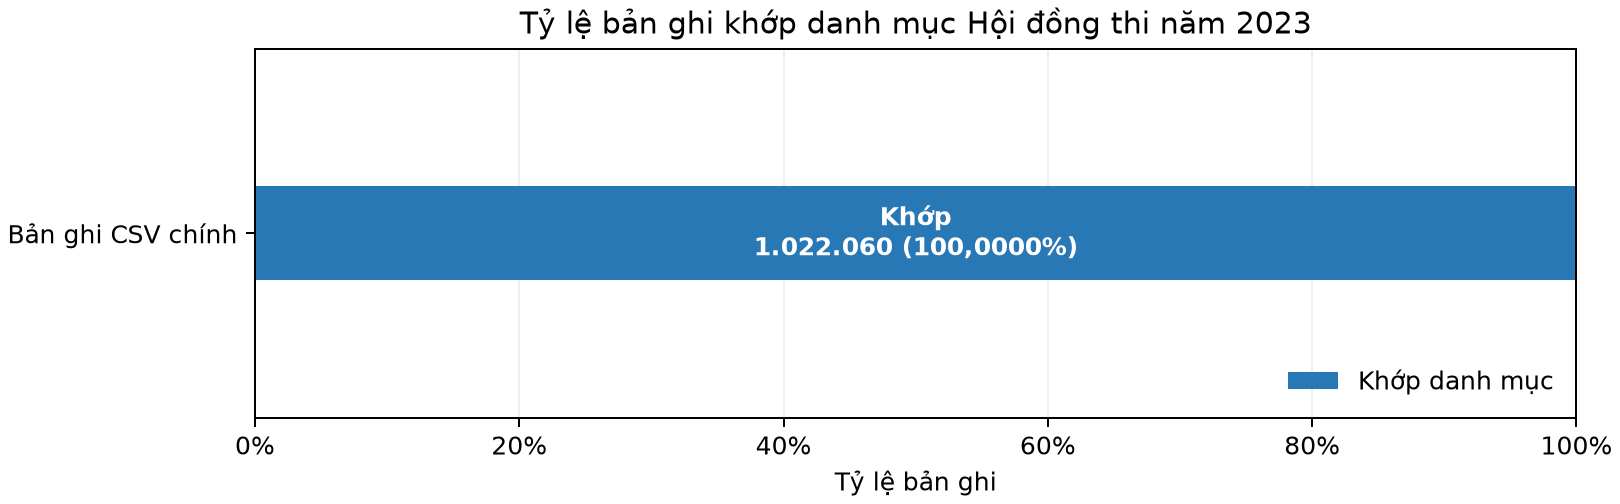


## EX5.3 — Dữ liệu cuối, nhật ký và điều kiện tái lập

CSV cuối có 11 cột gốc và 5 cột ngữ cảnh. Các cột điểm được giữ trong thang đo 0–10; mã thí sinh
và mã Hội đồng thi lưu kiểu chuỗi để bảo toàn số 0 đầu. Bảng bên dưới chỉ in schema, không in ID
của từng thí sinh.


In [4]:
final = pd.read_csv(_root / 'data/processed/week5_final+du_lieu_cuoi.csv', dtype={
    'Student ID': 'string', 'Foreign language code': 'string',
    'exam_council_code': 'string', 'exam_council_name': 'string',
    'observed_exam_group': 'string', 'merge_status': 'string'},
    keep_default_na=False, na_values=[''])
print('Kích thước:', final.shape)
print('Cột:', ', '.join(final.columns))
print('\nNhóm điểm quan sát:')
print(final['observed_exam_group'].value_counts(dropna=False).to_string())
print('\nTrạng thái ghép:')
print(final['merge_status'].value_counts(dropna=False).to_string())


Kích thước: (1022060, 16)
Cột: Student ID, Mathematics, Literature, Foreign language, Physics, Chemistry, Biology, History, Geography, Civic education, Foreign language code, exam_year, exam_council_code, exam_council_name, observed_exam_group, merge_status

Nhóm điểm quan sát:
observed_exam_group
social_only         683813
science_only        329430
neither_observed      8817

Trạng thái ghép:
merge_status
matched    1022060


In [5]:
log = pd.read_csv(_root / 'outputs/tables/week5_cleaning_log+nhat_ky_lam_sach.csv', keep_default_na=False)
print('Quyết định Cleaning Log theo tuần:')
print(log['week'].value_counts().sort_index().to_string())
print('\nCác quyết định mới Week 5:')
print(log.loc[log['week'].astype(str).eq('5'),
              ['ID', 'column_or_record', 'issue', 'decision', 'scope_rows', 'changed_rows']]
      .to_string(index=False))


Quyết định Cleaning Log theo tuần:
week
3    17
4    18
5     8

Các quyết định mới Week 5:
   ID             column_or_record                                 issue                                                    decision  scope_rows  changed_rows
CL036              Toàn bộ bản ghi               Bản ghi trùng hoàn toàn                   Không loại; không có dòng trùng hoàn toàn     1022060             0
CL037                   9 cột điểm                    Giá trị điểm thiếu                                                    Giữ null     3394966             0
CL038                   9 cột điểm                     Ngoại lệ thống kê                                Gắn cờ để điều tra; giữ điểm       34857             0
CL039                   Student ID                       Chuẩn hóa chuỗi                     Chuẩn hóa; không sửa nếu đã đạt quy tắc     1022060             0
CL040        Foreign language code                       Chuẩn hóa chuỗi                     Chuẩn hóa; không sửa

## Lệnh chạy lại từ nguồn raw

Tại thư mục gốc PowerShell: `& .venv/Scripts/python.exe src/main.py`.
Manifest, merge diagnostics, outlier details, missing summary, text checks, pipeline log,
Cleaning Log và từ điển dữ liệu được lưu ở `outputs/`.
